In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/Pikky Assignment/food dataset.csv')

Prior to this analysis in Python, preliminary data cleaning was carried out using Microsoft Excel. It was focused on removing columns with a substantial proportion of missing values to enhance data quality.

# Problem Statement

To explore and analyze food ingredient data to identify patterns, relationships, and trends in nutritional content, dietary suitability (e.g., for keto, Jain, Halal diets), and sensory attributes (taste, texture, aroma), with the goal of deriving actionable insights for ingredient categorization, health-based filtering, and potential product development.


# Knowing Dataset

In [33]:
df.head()

,classification,ingredientType,subClassification,ingredient_name,measuring_unit,secondary_measuring_unit,primary_quantity,bone_existence,fat_percentage,nutritional_values.protein.amount(gm),...,nutritional_values.calcium.amount(mg),nutritional_values.sodium.amount(mg),nutritional_values.potassium.amount(mg),nutritional_values.iron.amount(%),tags.mouthfeel[0],tags.mouthfeel[1],tags.mouthfeel[2],nutritional_values.sugars.amount(gm),nutritional_values.vitaminA.amount(mg),nutritional_values.vitaminsC.amount(mg)
0,plant processed,plant based oil,plant based fats & oils,white truffle oil,ml,cup,14.0,no,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,plant processed,plant based milk,dairy alternatives,macademia milk,ml,glass,250.0,no,NaN,0.4,...,182.0,40.0,0.0,0.96,buttery,mouthcoating,NaN,NaN,NaN,NaN
2,plant processed,plant based oil,plant based fats & oils,light olive oil,ml,cup,100.0,no,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
3,plant processed,plant based fats,plant based fats & oils,cocoa butter oil,ml,tsp,14.0,no,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
4,plant natural,rice,grains,american longgrain rice,gm,cup,45.0,NR,NaN,3.0,...,21.0,NaN,427.0,2.00,tender,mild chewy,slightly toothsome,NaN,0.0,0.0


In [34]:
# Dataset Rows & Columns count
df.shape

(3072, 46)

In [35]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

In [36]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 46 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   classification                                3072 non-null   object 
 1   ingredientType                                3072 non-null   object 
 2   subClassification                             3072 non-null   object 
 3   ingredient_name                               3072 non-null   object 
 4   measuring_unit                                3071 non-null   object 
 5   secondary_measuring_unit                      3068 non-null   object 
 6   primary_quantity                              3013 non-null   float64
 7   bone_existence                                3072 non-null   object 
 8   fat_percentage                                778 non-null    object 
 9   nutritional_values.protein.amount(gm)         2171 non-null   f

In [37]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
classification,0
ingredientType,0
subClassification,0
ingredient_name,0
measuring_unit,1
secondary_measuring_unit,4
primary_quantity,59
bone_existence,0
fat_percentage,2294
nutritional_values.protein.amount(gm),901


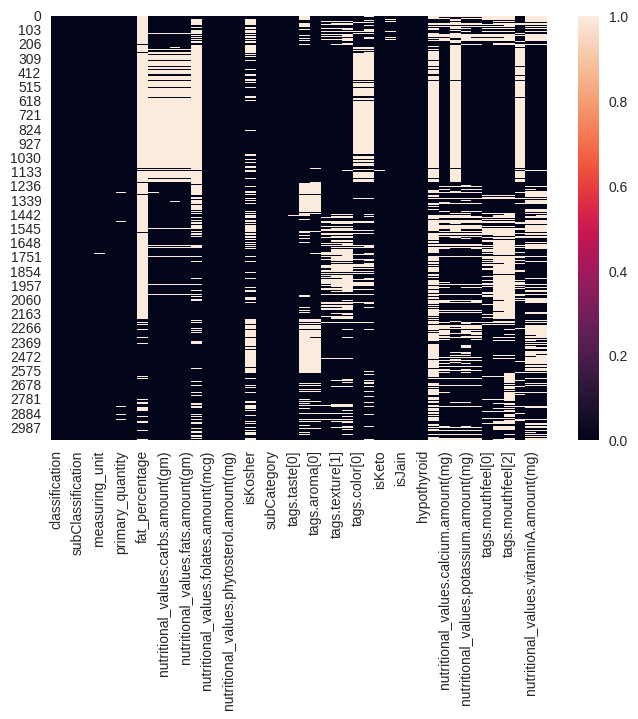

In [38]:
# Visualizing the missing values
# Checking Null Values by Plotting Heatmap

sns.heatmap(df.isnull(), cbar=True)
plt.show()

## Key Observations:

A significant number of columns have no missing values, indicating good data completeness for these features.
Several nutritional value columns (protein, carbs, calories, fats, cholesterol, dietary_fibers, calcium, sodium, potassium, iron, sugars, vitaminA, vitaminsC) have a substantial amount of missing data.
The fat_percentage and nutritional_values.dietary_fibers.amount(mg) columns have the highest number of missing values.
Columns related to tags (taste, aroma, texture, color, mouthfeel) also exhibit varying degrees of missingness, with later indexed tag elements generally having more missing values.
isKosher also has a high number of missing values.
This summary highlights which columns might require attention for data cleaning or imputation depending.  The nature of each column and the potential impact of these missing values on your results is needed to be considered.

In [39]:
# Mode Imputation for categorical columns
df['measuring_unit'].fillna(df['measuring_unit'].mode()[0], inplace=True)
df['secondary_measuring_unit'].fillna(df['secondary_measuring_unit'].mode()[0], inplace=True)
df['fodmap'].fillna('Unknown', inplace=True)
df['isKeto'].fillna('Unknown', inplace=True)
df['tags.taste[0]'].fillna(df['tags.taste[0]'].mode()[0], inplace=True)

# Median/Mean Imputation for numeric columns
df['primary_quantity'].fillna(df['primary_quantity'].median(), inplace=True)
df['nutritional_values.folates.amount(mcg)'].fillna(df['nutritional_values.folates.amount(mcg)'].mean(), inplace=True)
df['nutritional_values.magnesium.amount(mg)'].fillna(df['nutritional_values.magnesium.amount(mg)'].mean(), inplace=True)
df['nutritional_values.phytosterol.amount(mg)'].fillna(df['nutritional_values.phytosterol.amount(mg)'].mean(), inplace=True)


In [40]:
# Impute 'isKosher' with 'Unknown' (could also use False if binary)
df['isKosher'].fillna('Unknown', inplace=True)
df['tags.mouthfeel[0]'].fillna('Unknown', inplace=True)

# Impute numerical nutrition columns with median or mean
df['nutritional_values.calcium.amount(mg)'].fillna(df['nutritional_values.calcium.amount(mg)'].median(), inplace=True)
df['nutritional_values.iron.amount(%)'].fillna(df['nutritional_values.iron.amount(%)'].mean(), inplace=True)
df['nutritional_values.potassium.amount(mg)'].fillna(df['nutritional_values.potassium.amount(mg)'].median(), inplace=True)
df['nutritional_values.sodium.amount(mg)'].fillna(df['nutritional_values.sodium.amount(mg)'].median(), inplace=True)
df['nutritional_values.sugars.amount(gm)'].fillna(df['nutritional_values.sugars.amount(gm)'].median(), inplace=True)
df['nutritional_values.vitaminA.amount(mg)'].fillna(df['nutritional_values.vitaminA.amount(mg)'].median(), inplace=True)
df['nutritional_values.vitaminsC.amount(mg)'].fillna(df['nutritional_values.vitaminsC.amount(mg)'].median(), inplace=True)




In [41]:
# Drop columns with more than 70% missing values
cols_to_drop = [
    'nutritional_values.dietary_fibers.amount(mg)',
    'tags.mouthfeel[1]',
    'tags.mouthfeel[2]',
    'tags.color[0]',
    'tags.color[1]'
]

df.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns due to high missing values:", cols_to_drop)


Dropped columns due to high missing values: ['nutritional_values.dietary_fibers.amount(mg)', 'tags.mouthfeel[1]', 'tags.mouthfeel[2]', 'tags.color[0]', 'tags.color[1]']


In [42]:
# Fill TAG columns with 'Unknown'
tag_cols_to_fill = [
    'tags.taste[1]',
    'tags.aroma[0]',
    'tags.texture[0]',
    'tags.texture[1]',
    'tags.texture[2]'
]

for col in tag_cols_to_fill:
    df[col].fillna('Unknown', inplace=True)

df['fat_percentage'].fillna('Unknown', inplace=True)

# Impute missing nutritional values
df['nutritional_values.protein.amount(gm)'].fillna(df['nutritional_values.protein.amount(gm)'].median(), inplace=True)
df['nutritional_values.carbs.amount(gm)'].fillna(df['nutritional_values.carbs.amount(gm)'].median(), inplace=True)
df['nutritional_values.calories.amount(kcal)'].fillna(df['nutritional_values.calories.amount(kcal)'].median(), inplace=True)
df['nutritional_values.fats.amount(gm)'].fillna(df['nutritional_values.fats.amount(gm)'].median(), inplace=True)
df['nutritional_values.cholesterol.amount(mg)'].fillna(df['nutritional_values.cholesterol.amount(mg)'].median(), inplace=True)


In [43]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
classification,0
ingredientType,0
subClassification,0
ingredient_name,0
measuring_unit,0
secondary_measuring_unit,0
primary_quantity,0
bone_existence,0
fat_percentage,0
nutritional_values.protein.amount(gm),0


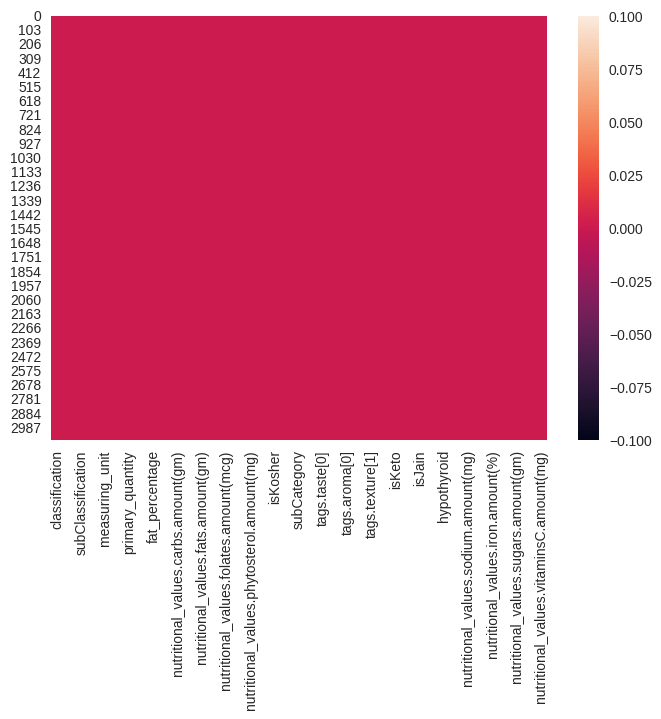

In [44]:
# Visualizing the missing values
# Checking Null Values by Plotting Heatmap

sns.heatmap(df.isnull(), cbar=True)
plt.show()

## Missing Values Handling Summary
**Categorical Columns** – Mode/Constant Imputation

- Filled missing values in measuring_unit, secondary_measuring_unit, and tags.taste[0] using the most frequent value (mode).

- Filled fodmap, isKeto, isKosher, and tags.mouthfeel[0] with 'Unknown' to retain the rows while preserving semantic clarity.

**Numerical Columns** – Median/Mean Imputation

- Used median to fill missing values in columns like primary_quantity, calcium, potassium, sodium, sugars, vitaminA, and vitaminsC to reduce the effect of outliers.

- Used mean for columns like folates, magnesium, phytosterol, and iron assuming a more normal distribution.

**Dropped Columns** with Excessive Missing Data

- Removed 5 more columns ( nutritional_values.dietary_fibers.amount(mg), and several tags fields) where over 70% of the data was missing, to improve data quality and reduce noise.



# EDA

## Understanding the dataset

In [45]:
df.info()
df.describe(include='all').T
classification_percent=df['classification'].value_counts(normalize=True).mul(100).round(2)
print(classification_percent)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 41 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   classification                             3072 non-null   object 
 1   ingredientType                             3072 non-null   object 
 2   subClassification                          3072 non-null   object 
 3   ingredient_name                            3072 non-null   object 
 4   measuring_unit                             3072 non-null   object 
 5   secondary_measuring_unit                   3072 non-null   object 
 6   primary_quantity                           3072 non-null   float64
 7   bone_existence                             3072 non-null   object 
 8   fat_percentage                             3072 non-null   object 
 9   nutritional_values.protein.amount(gm)      3072 non-null   float64
 10  nutritional_values.carbs

## Insights

Here’s the breakdown of the classification column:

**Classification	Proportion**

🌱 Plant Natural -	39.1%

🐄 Animal Natural	- 22.1%

🍖 Animal Processed -	20.4%

🧃 Plant Processed -	13.2%

🥤 Plant Based Beverage -	4.0%

🌶️ Plant Spices -	0.7%

⚗️ Chemicals	- 0.3%

🧂 Salt- 	0.1%

🥛 Beverage -	0.03%


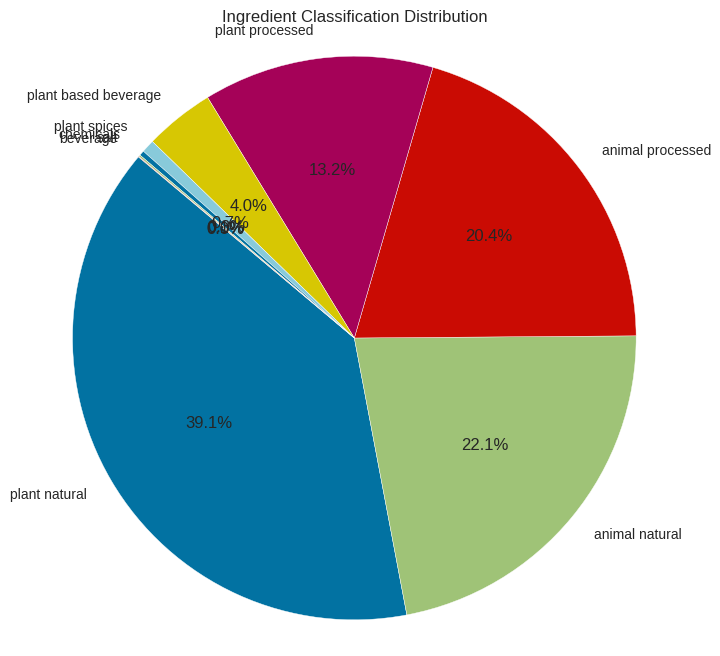

In [46]:
plt.figure(figsize=(8, 8))
plt.pie(classification_percent, labels=classification_percent.index, autopct='%1.1f%%', startangle=140)
plt.title('Ingredient Classification Distribution')
plt.axis('equal')
plt.show()

**1. Dominant Categories**

- Almost 40% of ingredients are `plant natural`, suggesting a plant-forward dataset.

- Animal-based ingredients (natural + processed) together form ~43%, indicating nearly equal representation of plant and animal sources.

- Processed foods (plant & animal) make up ~33.5%


## Univariate Analysis

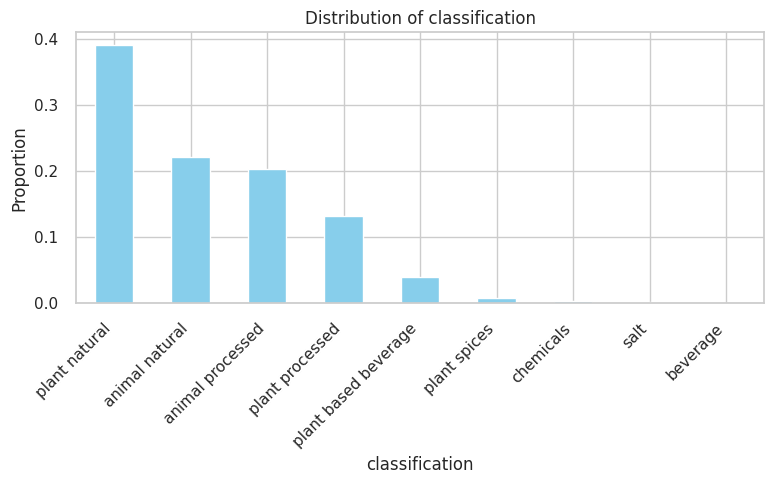

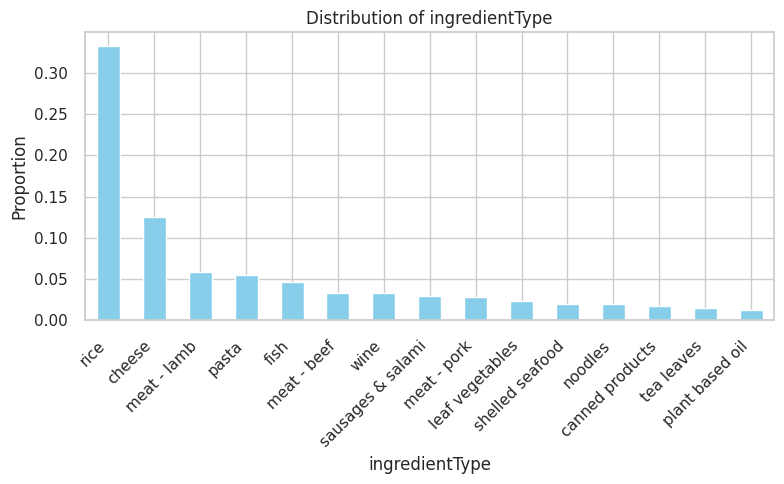

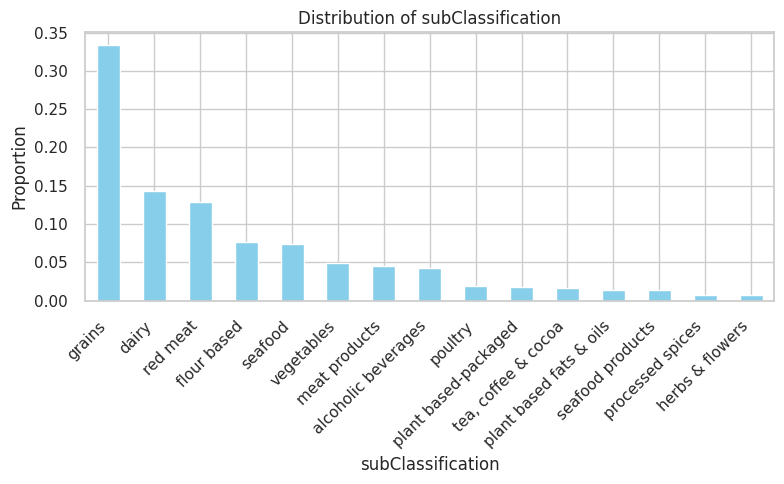

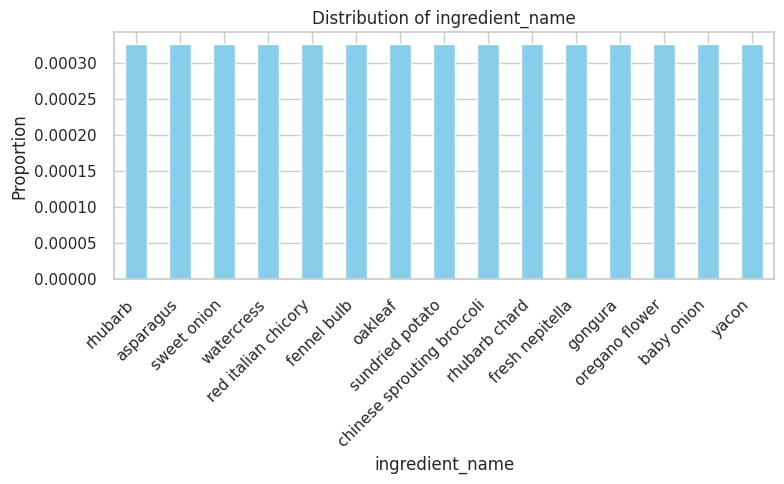

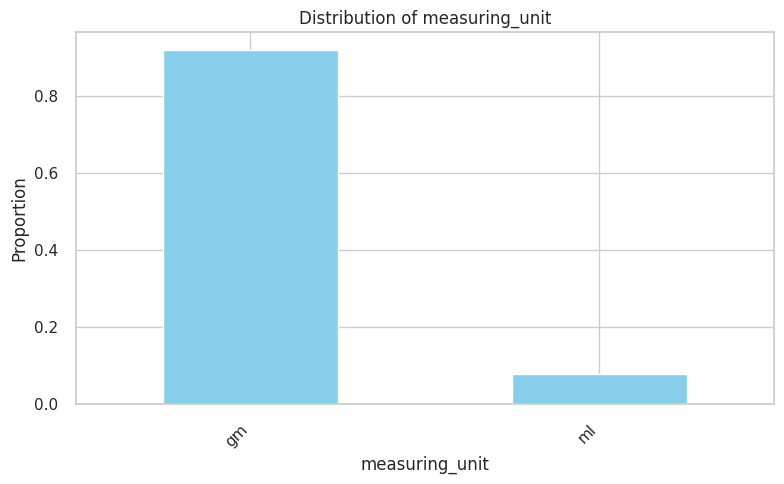

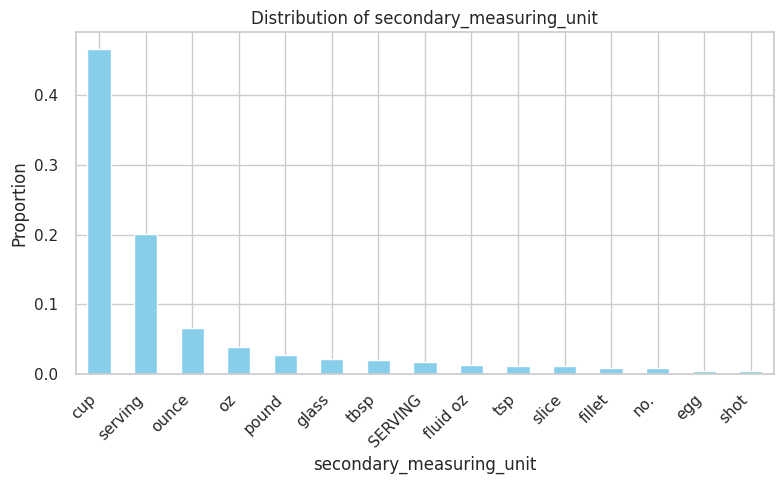

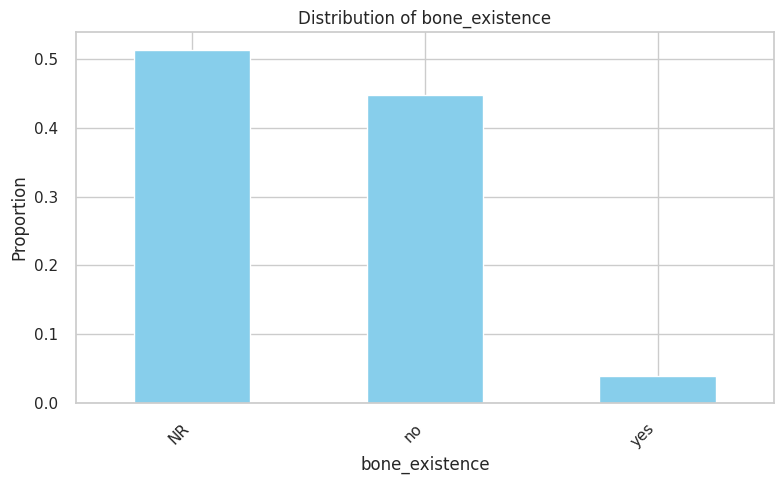

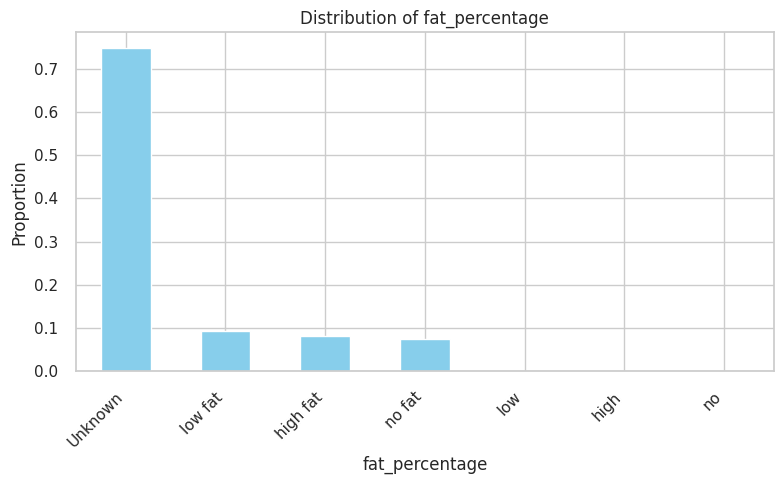

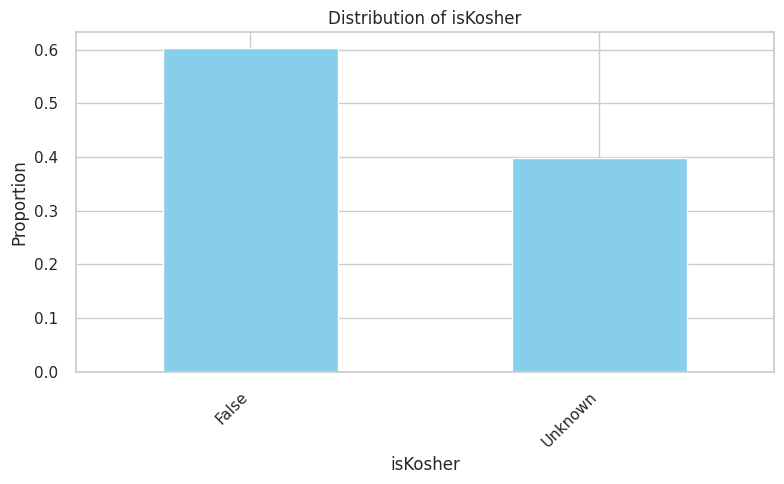

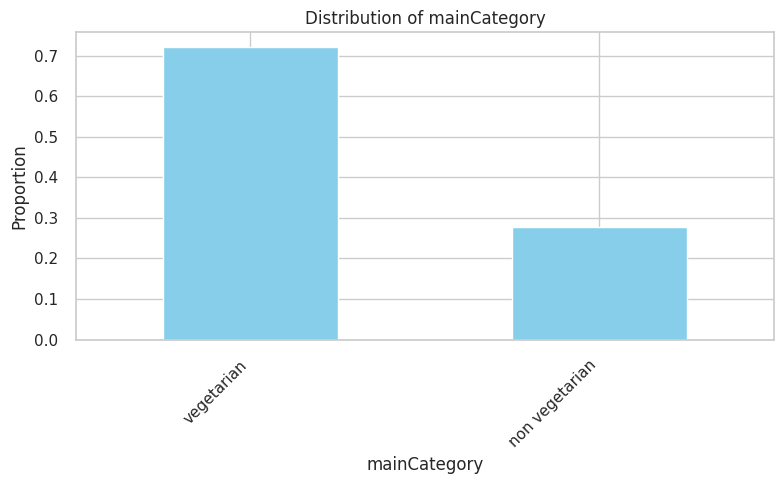

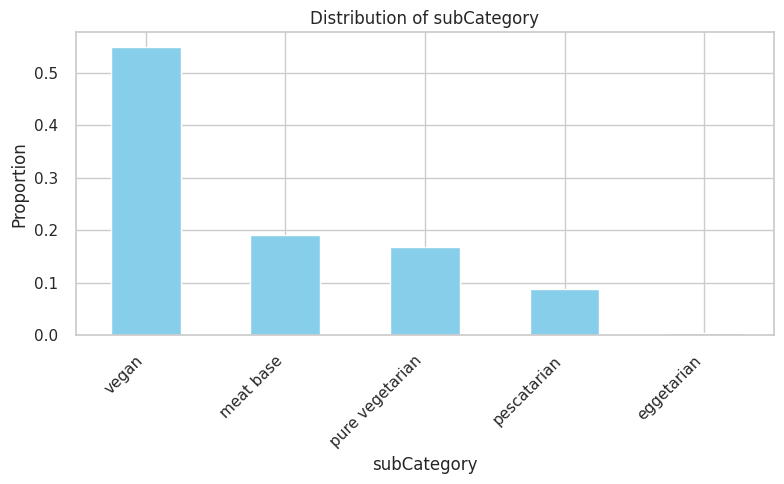

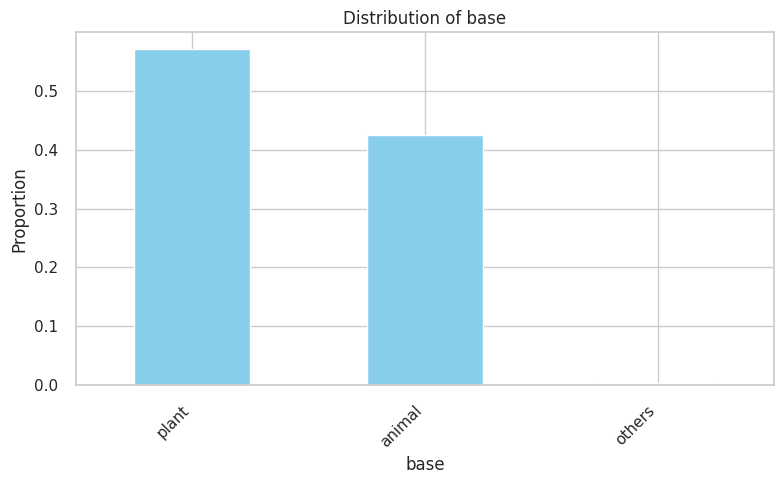

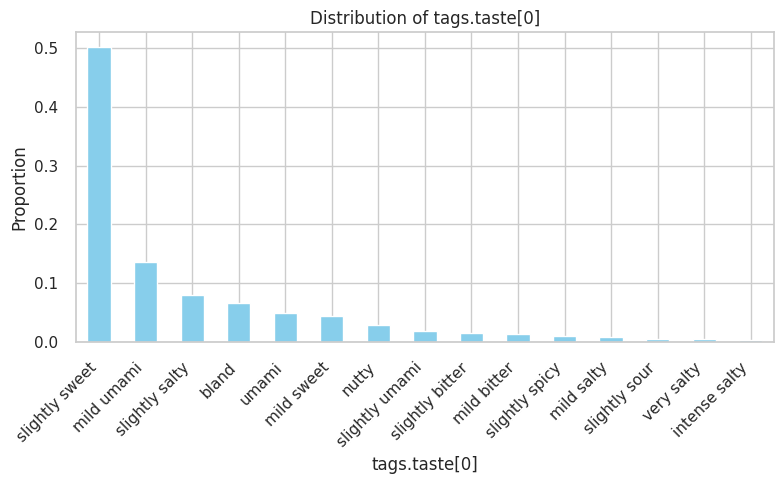

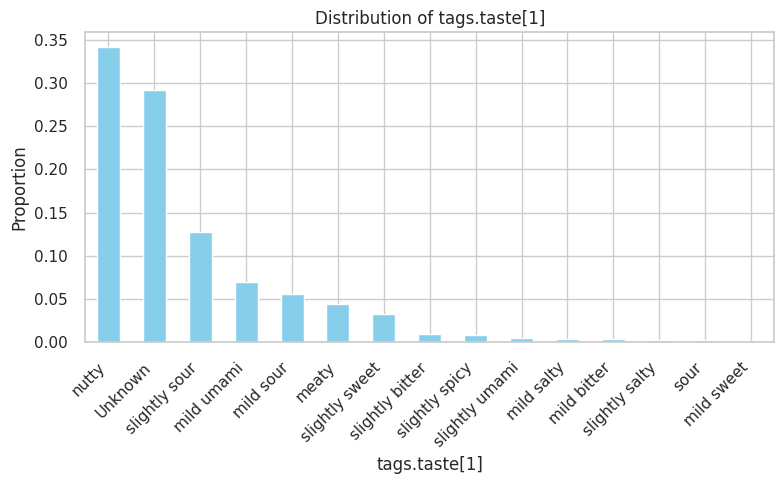

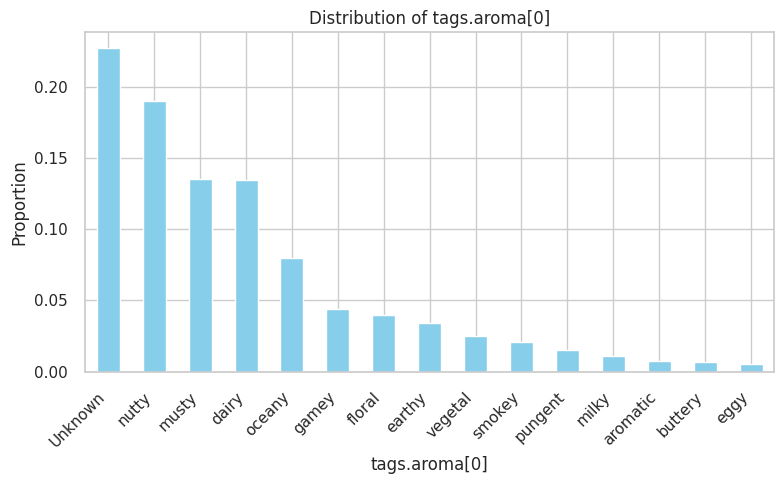

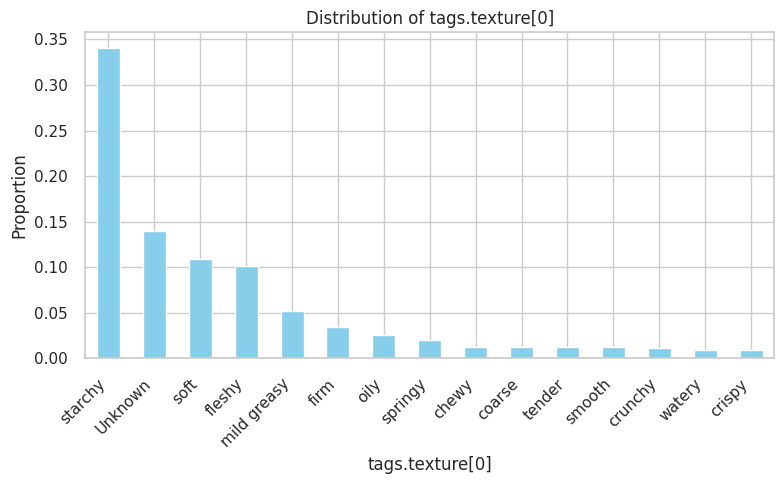

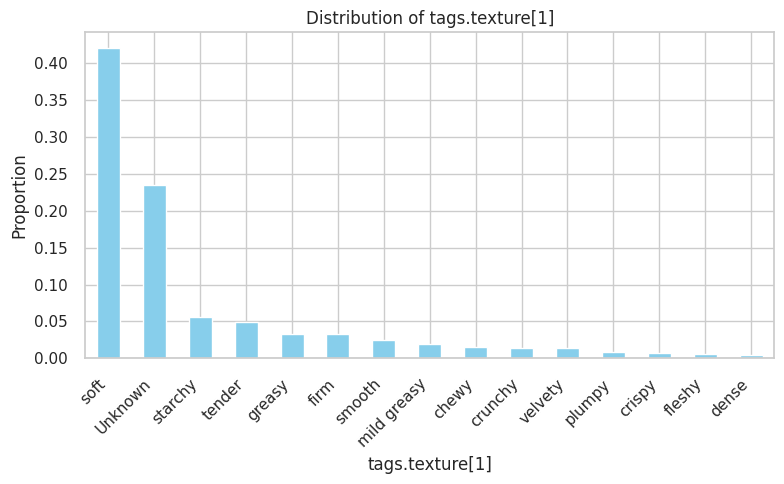

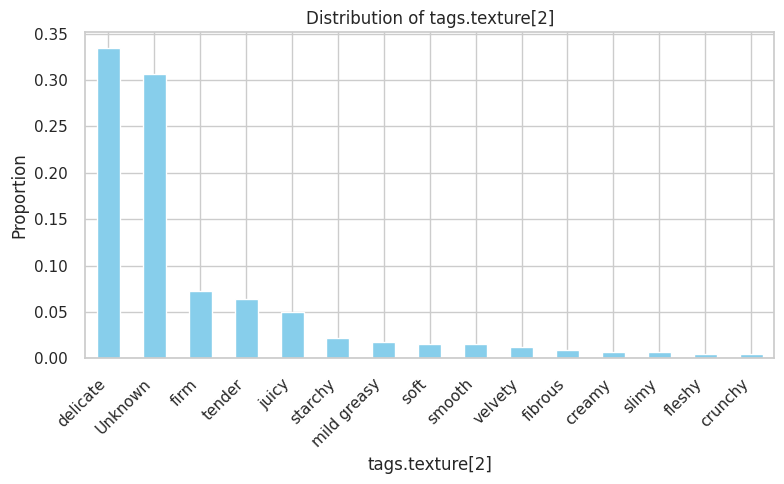

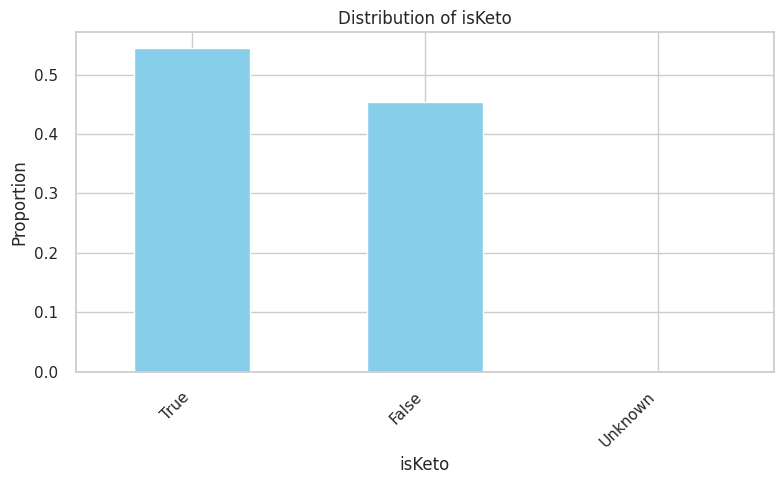

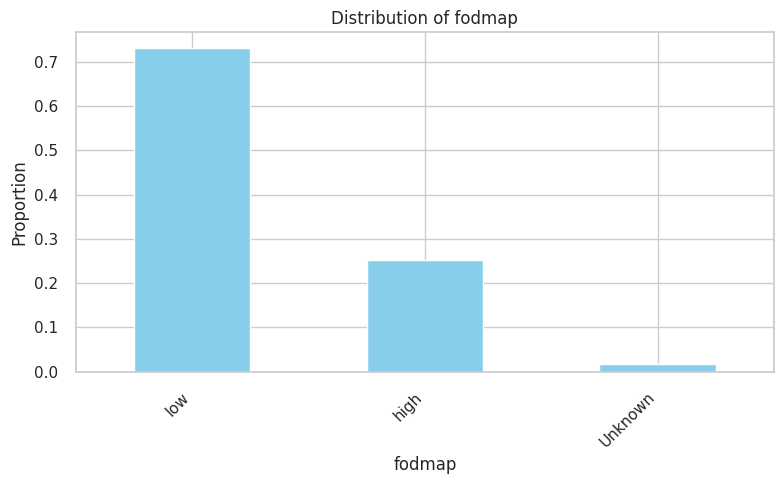

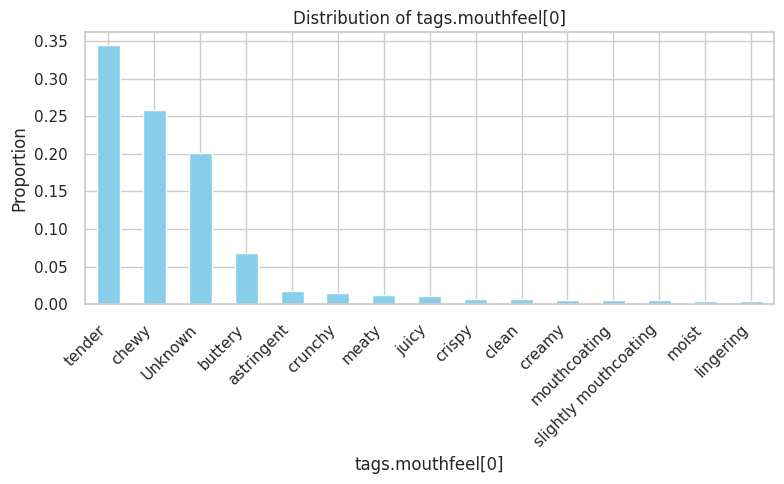

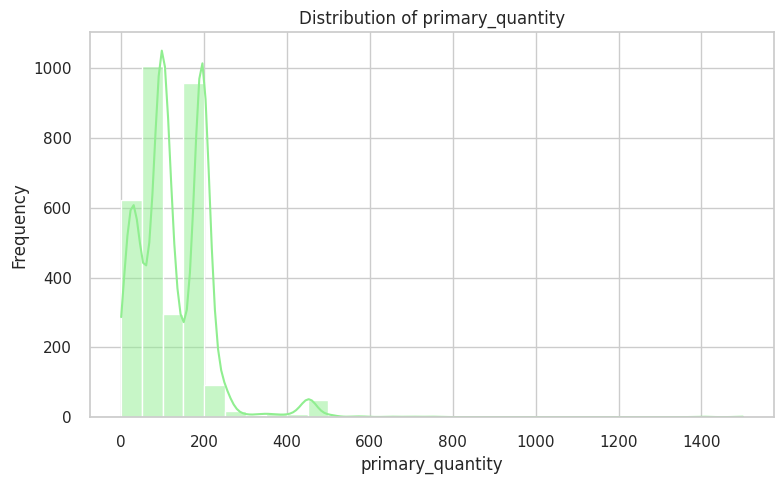

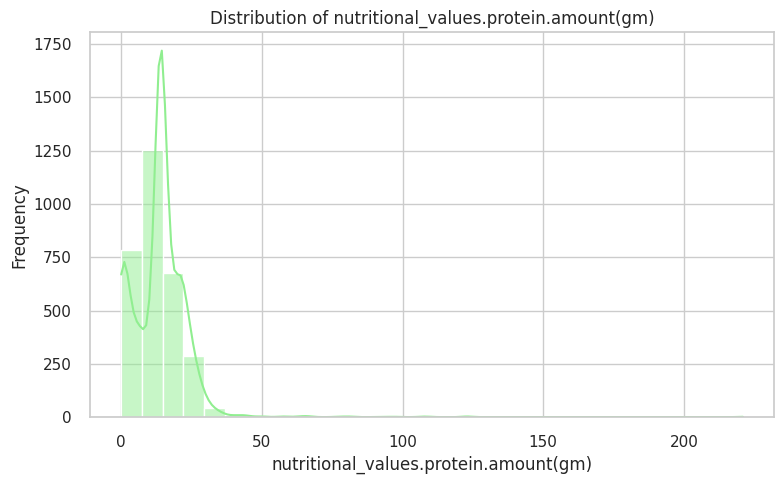

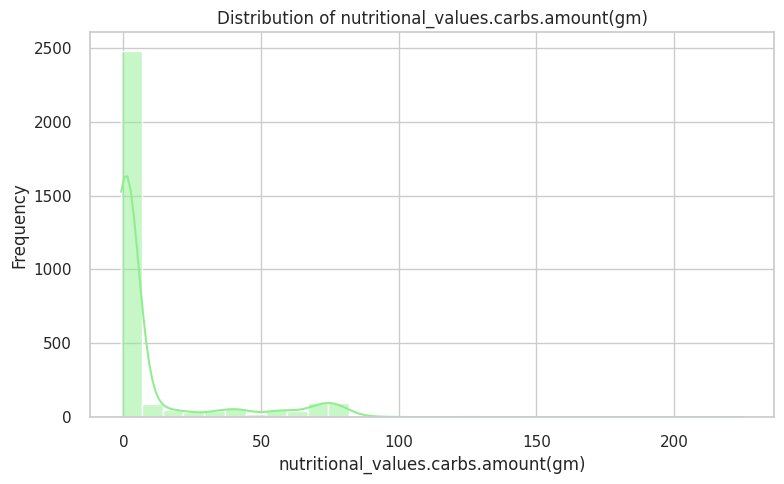

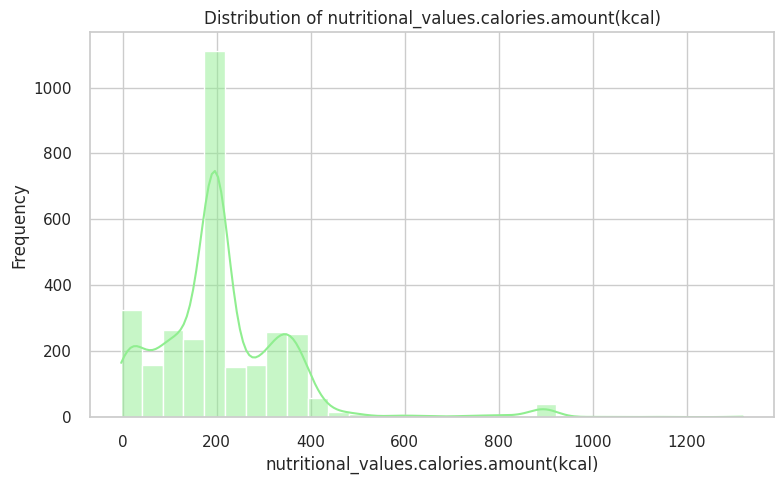

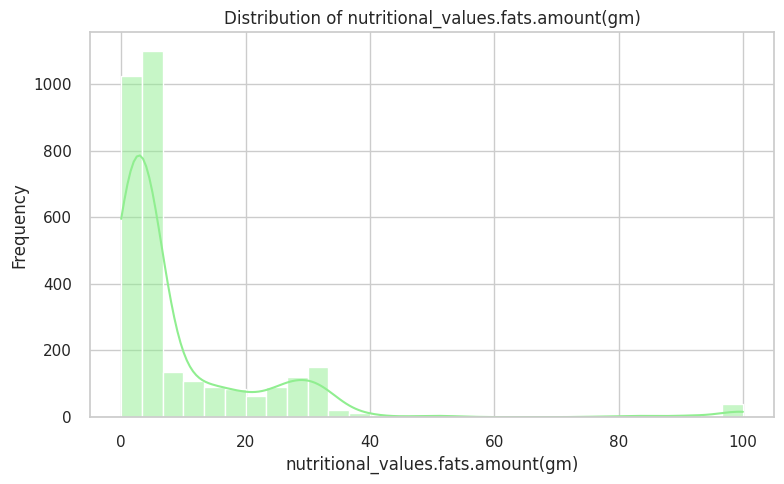

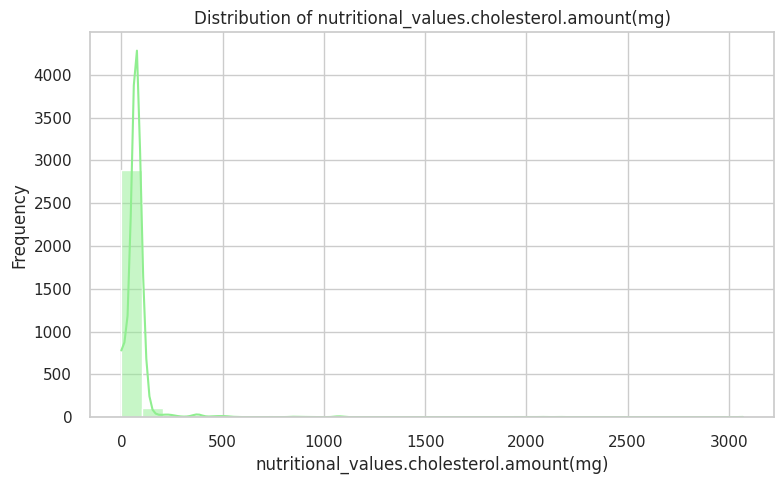

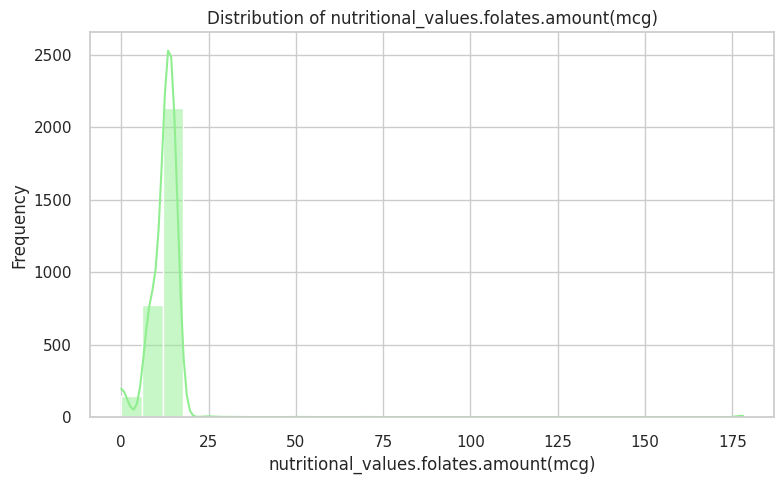

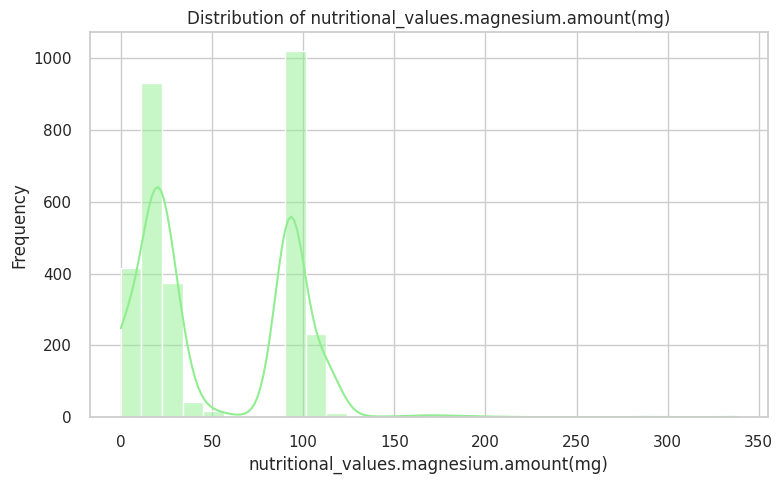

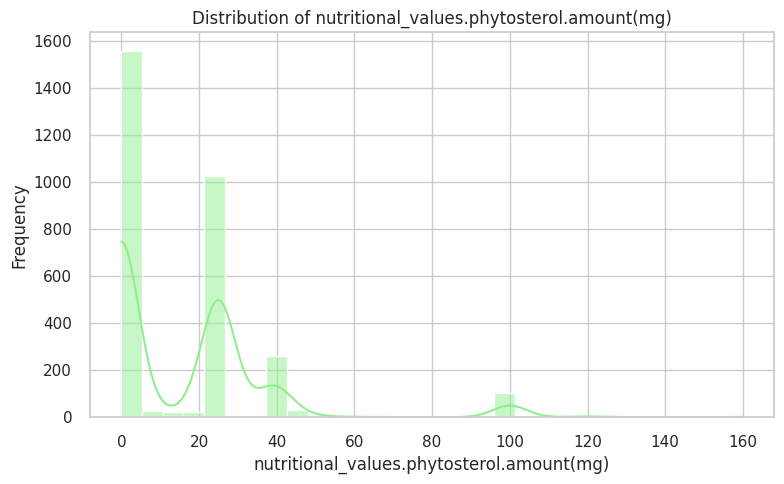

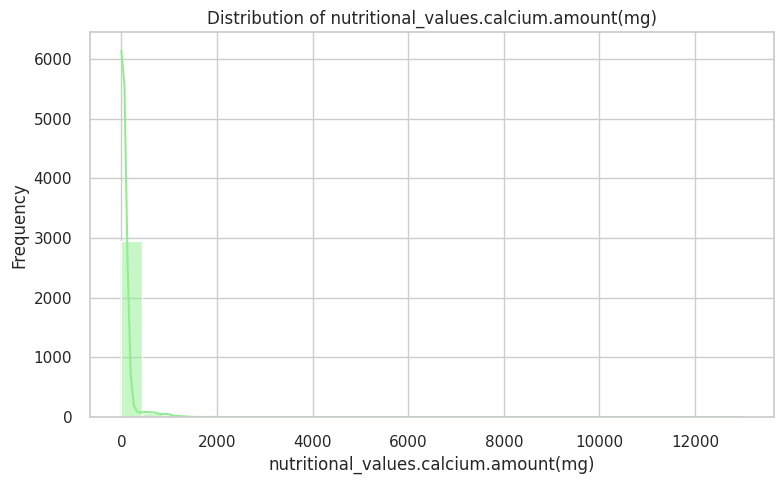

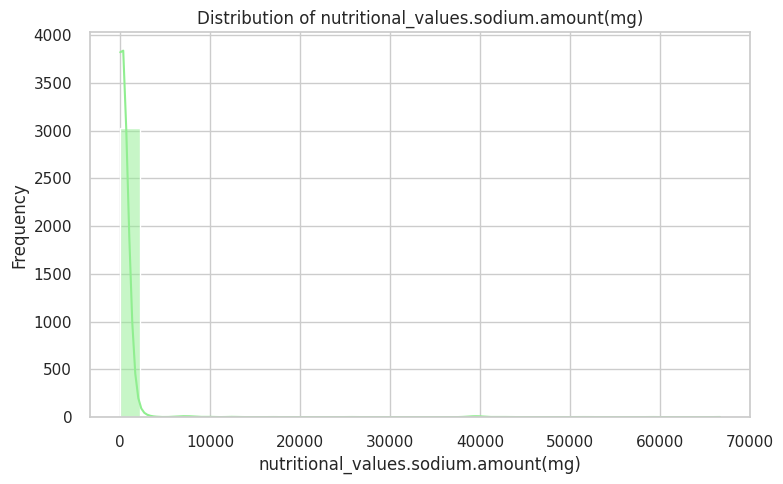

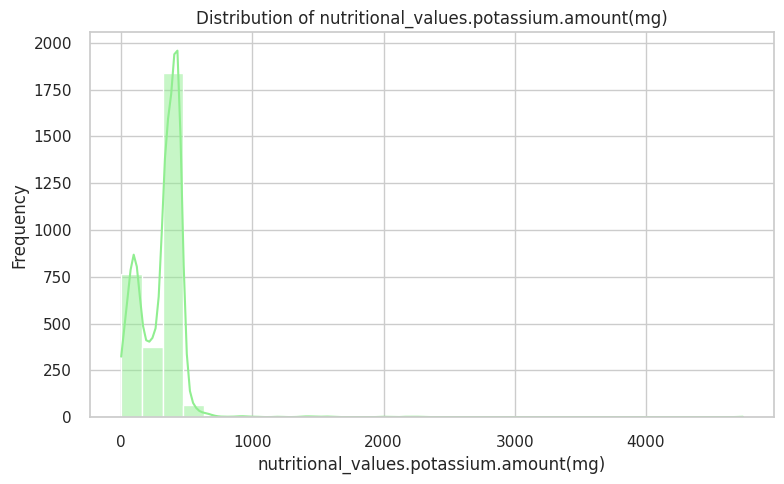

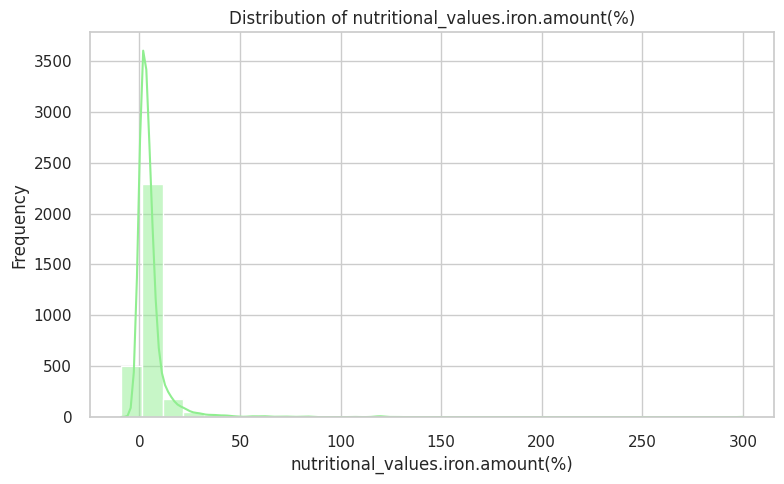

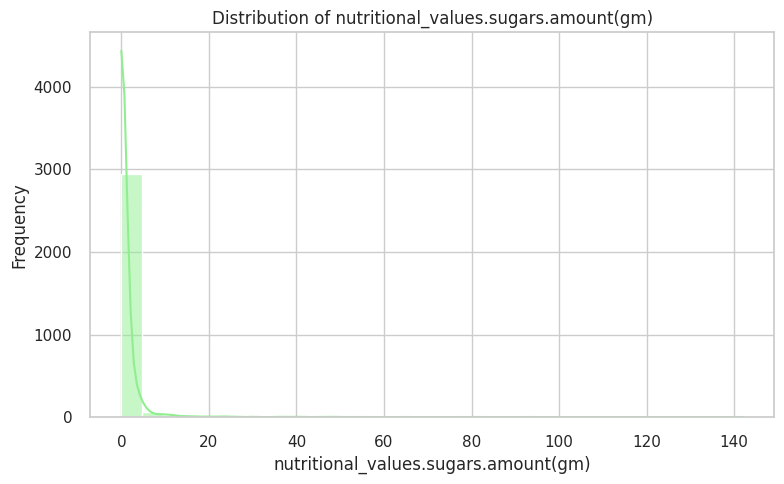

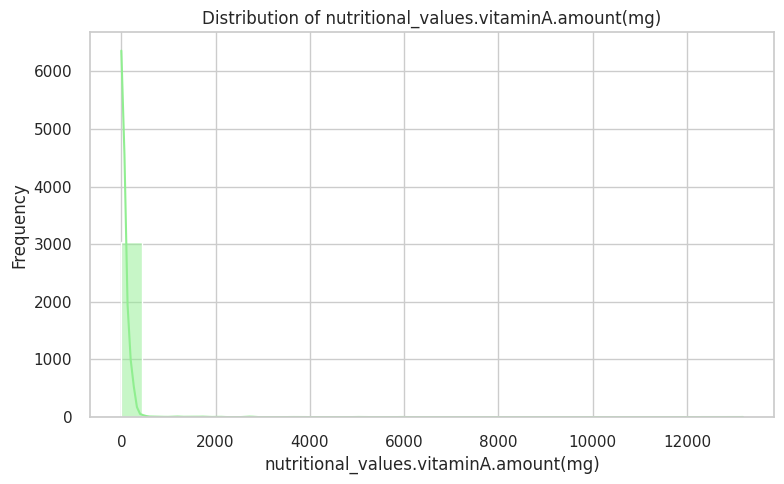

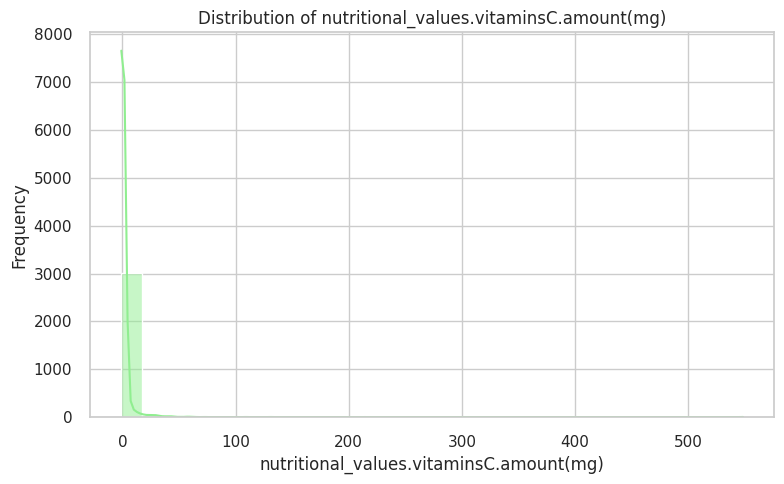

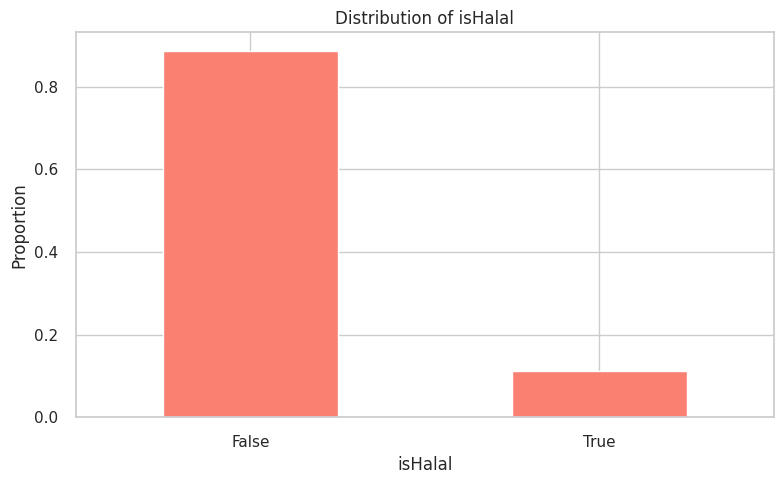

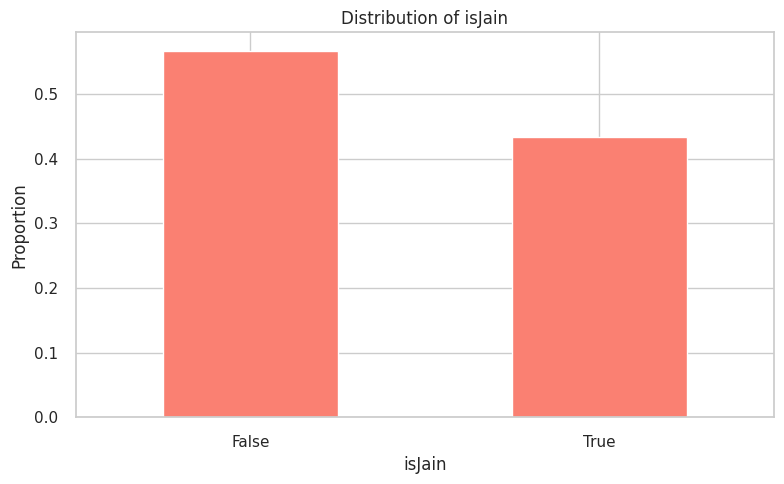

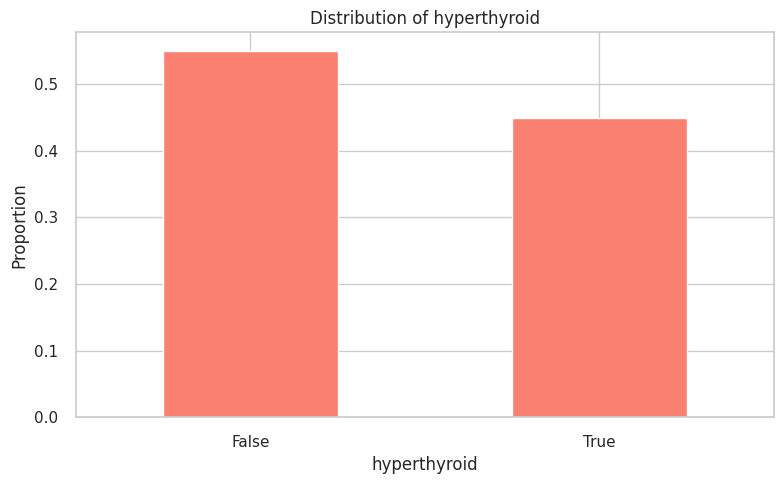

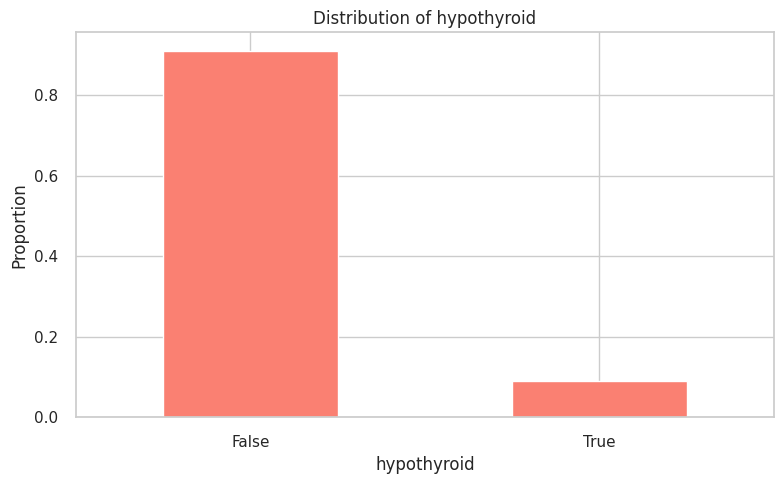

In [47]:

# Automatically detect column types
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
boolean_cols = df.select_dtypes(include=['bool']).columns

# Set a consistent style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# Univariate plots for categorical columns
for col in categorical_cols:
    plt.figure()
    df[col].value_counts(normalize=True).head(15).plot(kind='bar', color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.ylabel('Proportion')
    plt.xlabel(col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Univariate plots for numerical columns
for col in numerical_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30, color='lightgreen')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Univariate plots for boolean columns
for col in boolean_cols:
    plt.figure()
    df[col].value_counts(normalize=True).plot(kind='bar', color='salmon')
    plt.title(f'Distribution of {col}')
    plt.ylabel('Proportion')
    plt.xticks(ticks=[0,1], labels=['False', 'True'], rotation=0)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


### Insights
- "plant natural" and "animal natural" classifications have the highest proportions, while categories like "plant spices," "chemicals," "salt," and "beverage" have very low representation.

- "Rice" is the most frequent ingredient type, followed by "cheese" and "meat - lamb," while many other ingredient types have very low proportions.

- "Grains" represent the largest proportion of the sub-classifications, followed by "dairy" and "red meat," with many other sub-classifications having very small proportions.

- Cup is the most used secondary measuring unit, followed by Serving, and Ounce. Rest have very small proportions.

- More than 40% items have no bone existence, and less than 5% have, while more than half are not reported.

- Distribution of High, Low, and No fat is almost equal, while the fat level for about three-quarters of the products is unknown.

- 60% of items are not Kosher.

- More than 70% items are vegetarian, and more than 50% are vegan.

- More plant-based food items than animal-based.

- Slight sweet is the most occurring taste-tag, followed by mild Umami, Slightly salty, and bland. Other tastes have very low proportions.

- While Nutty, Musty, and Dairy are the most occurring aromas. A large proportion of it is unknown.

- Starchy is the texture with the most proportion, followed by Soft and Fleshy.

- More than half of the food items are Keto.

- About 3 quarter the items have low FODMAP.

- Tender is the most occurring mouthfeel, followed by Chewy.

- Primary quantities are mostly small, suggested by left skew of the distribution.

- Most foods have nutritional values in the 0-30 gm range

- Large number of foods have low-carb value.

- The calorie distribution shows a high frequency of recipes around the 200 kcal mark, suggesting a mix of lighter and moderately caloric dishes, and fewer very high-calorie options.

- The fat content is highly concentrated at very low values (around 0-5 grams), indicating a large number of low-fat recipes, with smaller peaks suggesting some recipes contain moderate or significantly higher amounts of fat.

- Most food items have low cholesterol value ranging in 0-100 mg.

- Most recipes in this dataset are not significant sources of folate.

- There is generally low magnesium content in recipes (0-30 mg), but few recipes do have around 100mg of magnesium, suggested by the two peaks.

- Most recipes contain minimal amounts of phytosterols and Calcium, Sodium, Vitamin A, C, and Sugar.

- The potassium content shows a high concentration of recipes with low amounts (around 200-400 mg), with a smaller peak around 0-100 mg.

- A vast amount (`~85%`) of items are not halal. And a considerable amount (~55%) is not suitable for Jain.

- More than half is Hyperthyroid, and only a small proportion is hypothyroid.


## Bivariate Analysis

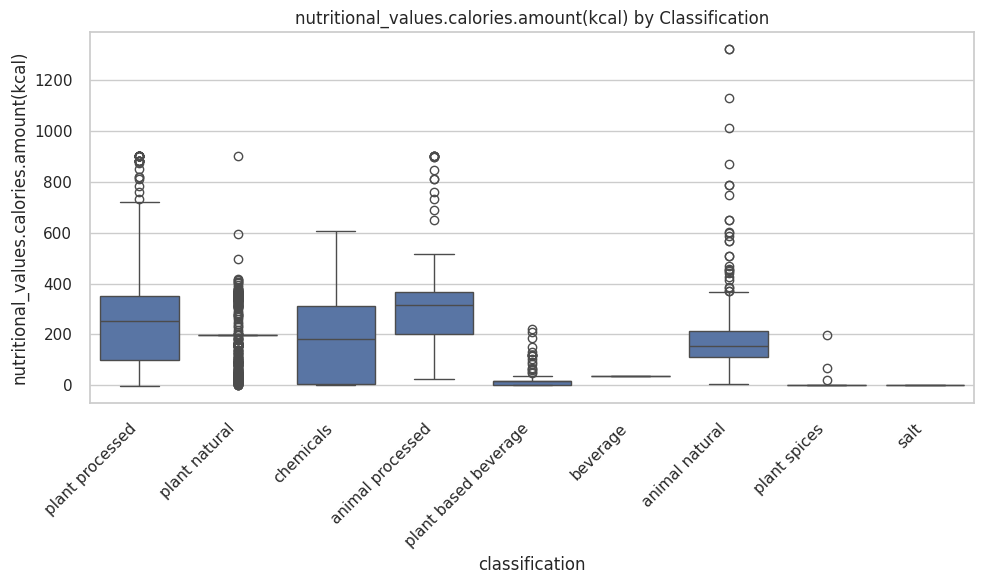

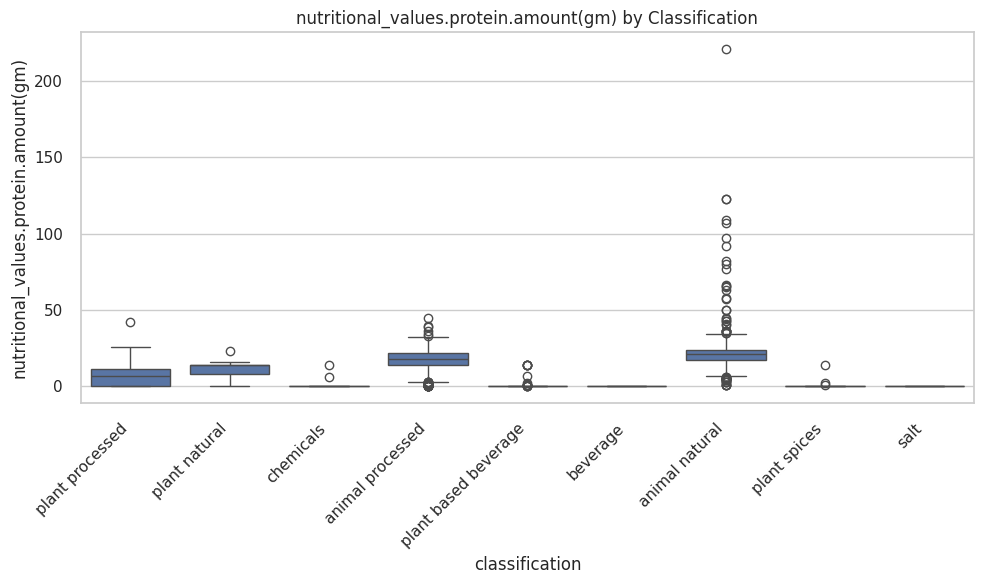

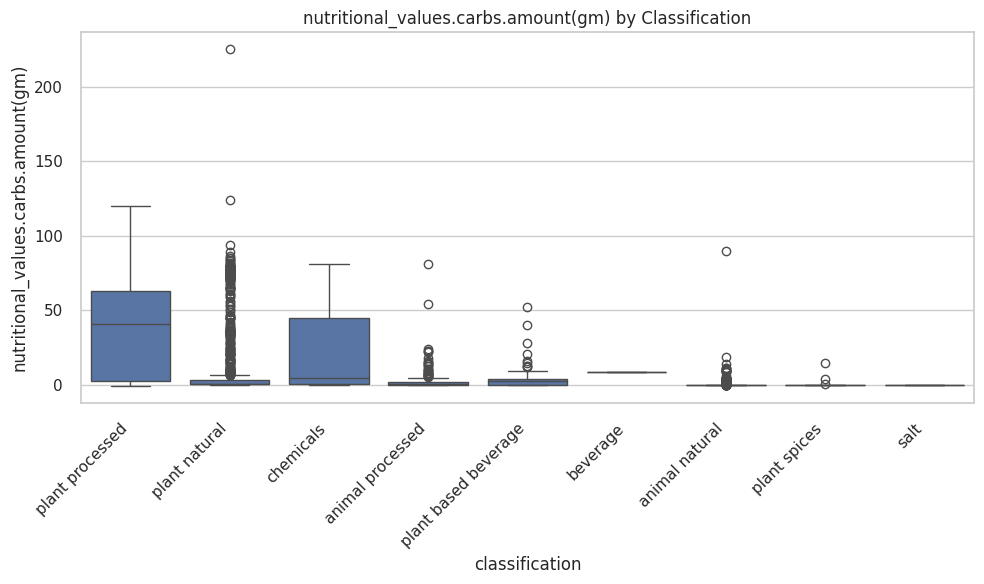

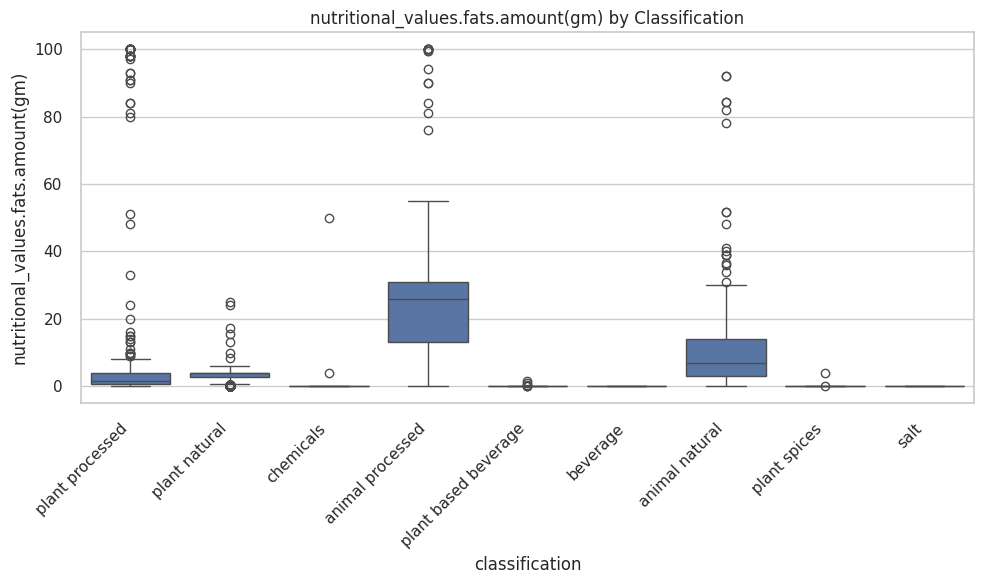

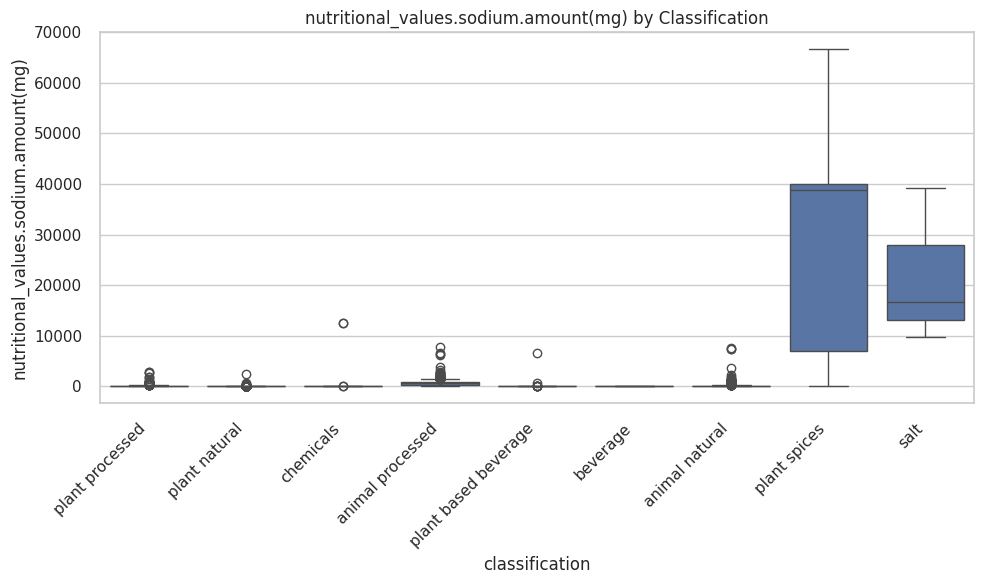

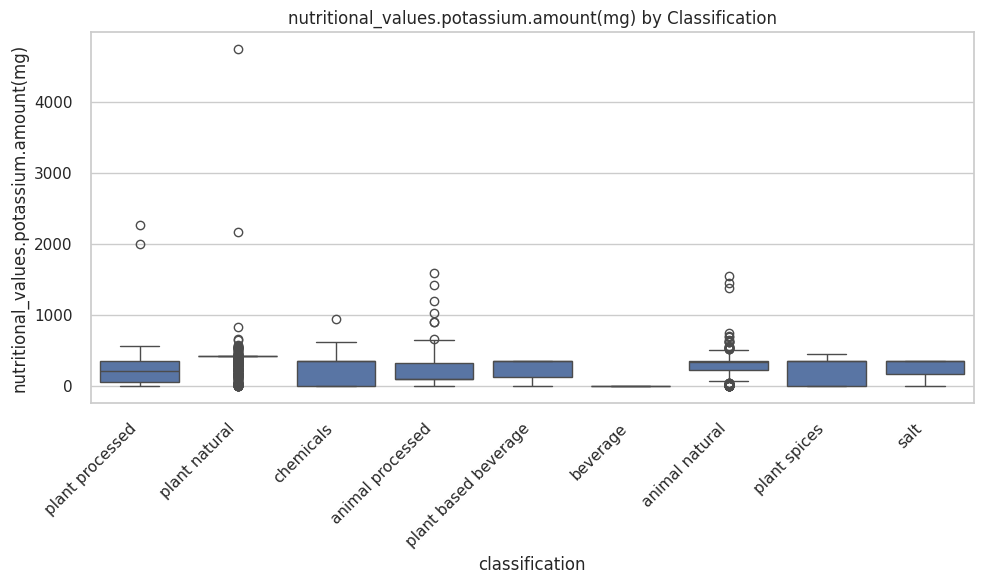

In [48]:
# Boxplot of important nutrients by classification
important_numerical = [
    'nutritional_values.calories.amount(kcal)',
    'nutritional_values.protein.amount(gm)',
    'nutritional_values.carbs.amount(gm)',
    'nutritional_values.fats.amount(gm)',
    'nutritional_values.sodium.amount(mg)',
    'nutritional_values.potassium.amount(mg)'
]

for col in important_numerical:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='classification', y=col)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{col} by Classification')
    plt.tight_layout()
    plt.show()


### Insights

- Animal processed and plant processed categories tend to have higher calorie counts with wider ranges, while plant based beverage, beverage, plant spices, and salt generally have very low calorie content.

- Animal based categories show higher protein content and a wider distribution, while beverage, plant based beverage, plant spices, and salt have minimal protein.

- Plant processed foods have the highest median and a wider range of carbohydrate content compared to other classifications.

- Animal processed foods show a significantly higher median and wider distribution of fat content.

- Plant Spices and Salt have high sodium content whereas Plant natural and animal natural categories exhibit higher median potassium levels

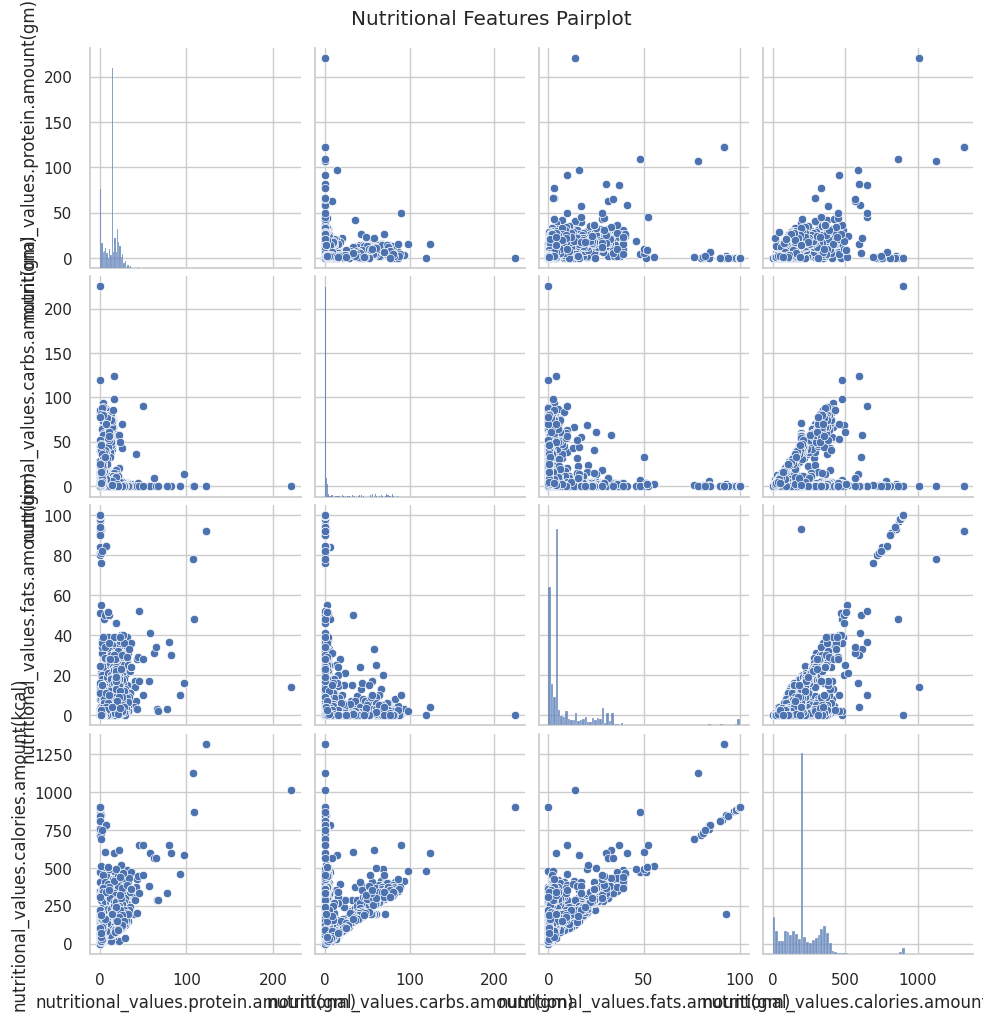

In [49]:
# Pair - plots for numerical relationships
pair_cols = [
    'nutritional_values.protein.amount(gm)',
    'nutritional_values.carbs.amount(gm)',
    'nutritional_values.fats.amount(gm)',
    'nutritional_values.calories.amount(kcal)'
]

# Pairplot for basic relationships
sns.pairplot(df[pair_cols])
plt.suptitle('Nutritional Features Pairplot', y=1.02)
plt.show()


The pairplot suggests positive correlations between protein, carbohydrates, fats, and calories, with calories appearing to have the strongest positive relationships with the other three nutritional features. The distributions along the diagonal show right-skewness for all four variables.

- Identifying nutrient correlations helps target specific customer needs (e.g., high-protein, low-fat for health-conscious buyers) and potentially spot opportunities for new product variations.

# Nutritional Pattern Analysis

**Correlation Heatmap for Nutritional Columns**

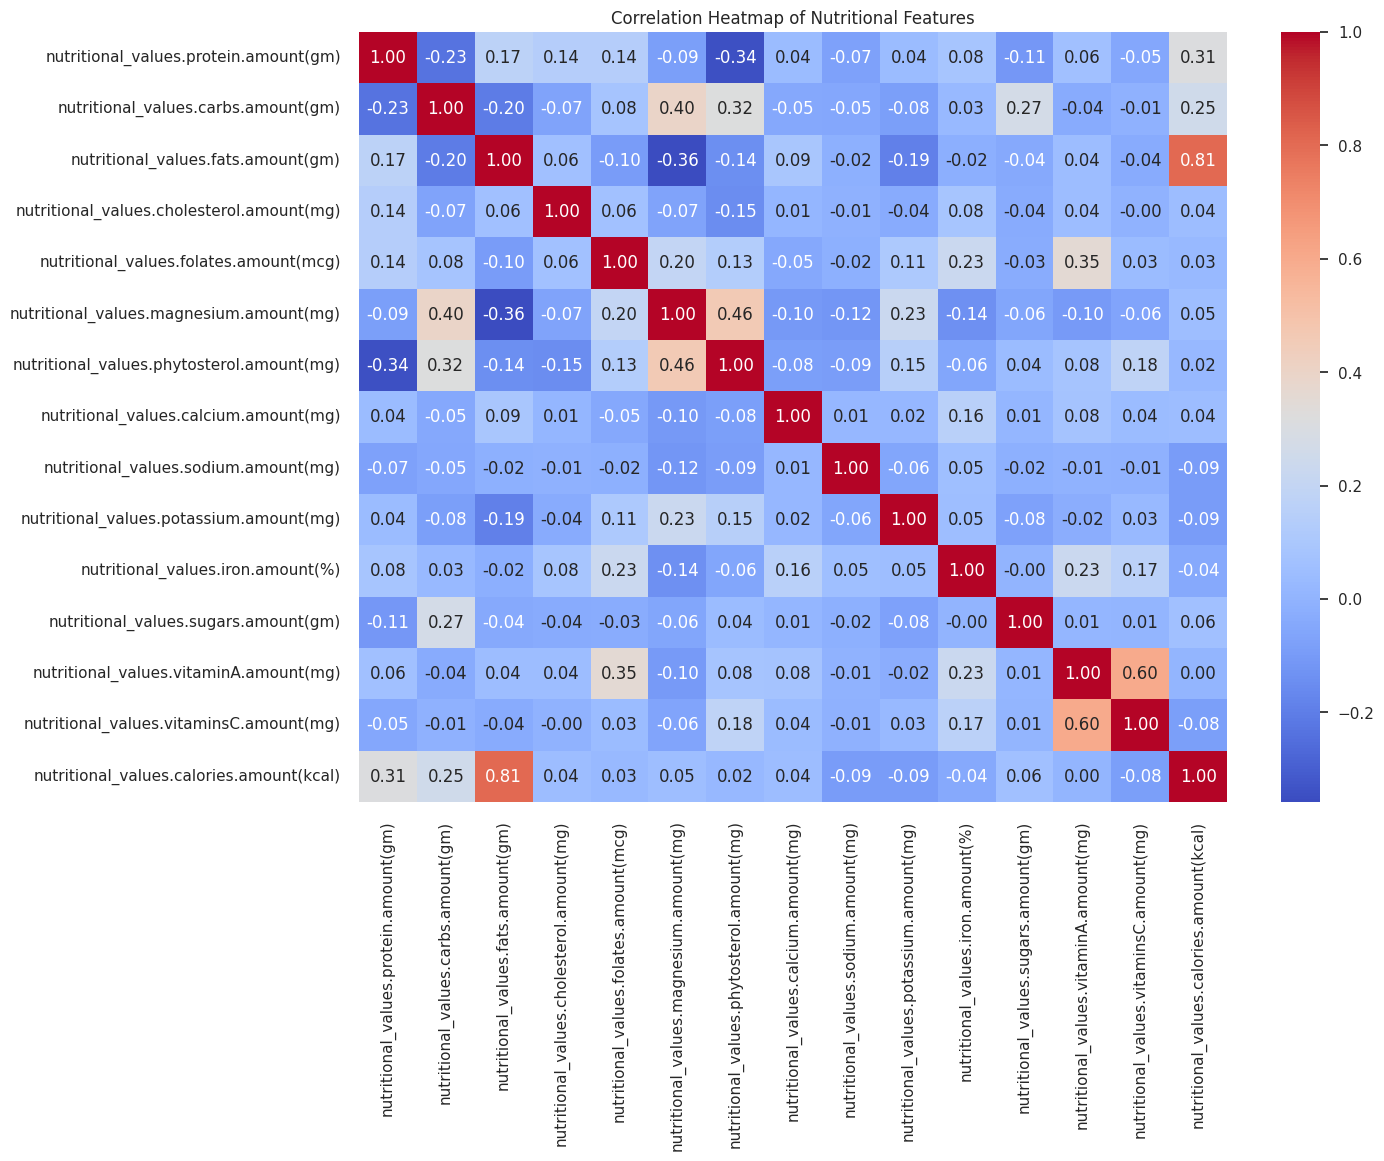

In [50]:
# Select nutrition-related columns
nutrition_cols = [
    'nutritional_values.protein.amount(gm)',
    'nutritional_values.carbs.amount(gm)',
    'nutritional_values.fats.amount(gm)',
    'nutritional_values.cholesterol.amount(mg)',
    'nutritional_values.folates.amount(mcg)',
    'nutritional_values.magnesium.amount(mg)',
    'nutritional_values.phytosterol.amount(mg)',
    'nutritional_values.calcium.amount(mg)',
    'nutritional_values.sodium.amount(mg)',
    'nutritional_values.potassium.amount(mg)',
    'nutritional_values.iron.amount(%)',
    'nutritional_values.sugars.amount(gm)',
    'nutritional_values.vitaminA.amount(mg)',
    'nutritional_values.vitaminsC.amount(mg)',
    'nutritional_values.calories.amount(kcal)'
]

# Compute correlation matrix
corr = df[nutrition_cols].corr()

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Nutritional Features")
plt.show()


## Insight

High positive correlations like between calories and fats/carbs/protein suggest that marketing energy-rich foods can emphasize these macronutrients. Conversely, strong negative correlations are less common here but could highlight opportunities for light or fortified product lines (e.g., low-sodium but high in a specific vitamin).

## Detect Nutritional Outliers

We’ll use Z-score

In [51]:
# Compute Z-scores
z_scores = df[nutrition_cols].apply(zscore)

# Identify outliers: abs(Z) > 3 in any nutrition column
outliers = df[(z_scores.abs() > 3).any(axis=1)]

print("Number of nutritional outliers:", outliers.shape[0])
outliers.head()


Number of nutritional outliers: 407


,classification,ingredientType,subClassification,ingredient_name,measuring_unit,secondary_measuring_unit,primary_quantity,bone_existence,fat_percentage,nutritional_values.protein.amount(gm),...,hyperthyroid,hypothyroid,nutritional_values.calcium.amount(mg),nutritional_values.sodium.amount(mg),nutritional_values.potassium.amount(mg),nutritional_values.iron.amount(%),tags.mouthfeel[0],nutritional_values.sugars.amount(gm),nutritional_values.vitaminA.amount(mg),nutritional_values.vitaminsC.amount(mg)
0,plant processed,plant based oil,plant based fats & oils,white truffle oil,ml,cup,14.0,no,Unknown,0.0,...,True,True,21.000000,116.0,348.0,5.542073,Unknown,0.0,0.0,0.0
2,plant processed,plant based oil,plant based fats & oils,light olive oil,ml,cup,100.0,no,Unknown,0.0,...,True,True,21.000000,116.0,348.0,5.542073,Unknown,0.0,0.0,0.0
3,plant processed,plant based fats,plant based fats & oils,cocoa butter oil,ml,tsp,14.0,no,Unknown,0.0,...,True,True,21.000000,116.0,348.0,5.542073,Unknown,0.0,0.0,0.0
6,plant natural,rice,grains,parboiled rice,gm,cup,158.0,no,Unknown,8.5,...,True,True,18.924051,0.0,55.7,12.151899,tender,0.2,0.0,0.0
7,plant processed,plant based oil,plant based fats & oils,sunflower oil,ml,tbsp,14.0,no,Unknown,0.0,...,True,True,21.000000,116.0,348.0,5.542073,Unknown,0.0,0.0,0.0


## Clustering (KMeans) for Nutritional Groupings

In [55]:
# Standardize the nutrition data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[nutrition_cols])

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['nutrition_cluster'] = kmeans.fit_predict(X_scaled)

# Count of ingredients in each cluster
print(df['nutrition_cluster'].value_counts())


nutrition_cluster
1    1585
0    1105
2     382
Name: count, dtype: int64


Note -> We n_clusters=3 based on exploratory observation — often food/nutrition items tend to cluster as:

High-protein/high-fat (e.g., animal products)

High-carb/low-fat (e.g., grains/sugary ingredients)

Balanced or moderate nutrition

In practice, we could run the Elbow Method to plot and find optimal k

In [56]:
# Cluster Profiling

# Group by cluster and get mean values
cluster_profile = df.groupby('nutrition_cluster')[nutrition_cols].mean().round(2)

# Transpose for better readability
cluster_profile.T


nutrition_cluster,0,1,2
nutritional_values.protein.amount(gm),11.81,16.17,8.61
nutritional_values.carbs.amount(gm),3.83,1.42,64.17
nutritional_values.calories.amount(kcal),173.22,215.74,312.59
nutritional_values.fats.amount(gm),3.69,15.82,2.57
nutritional_values.cholesterol.amount(mg),65.28,87.20,59.96
nutritional_values.folates.amount(mcg),15.11,10.29,14.43
nutritional_values.magnesium.amount(mg),84.27,17.30,98.65
nutritional_values.phytosterol.amount(mg),31.98,1.34,33.40
nutritional_values.calcium.amount(mg),28.98,112.65,22.68
nutritional_values.sodium.amount(mg),148.49,822.50,107.50


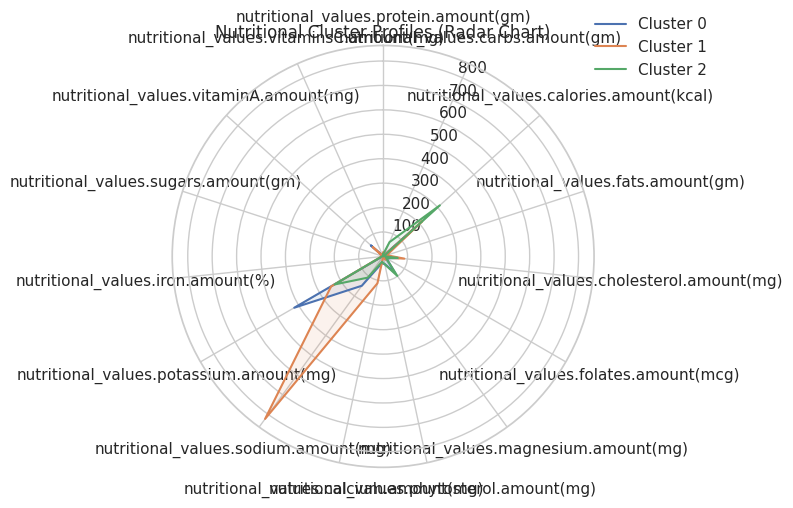

In [57]:
# Visualize Cluster Profiles with Radar Chart

# Prepare data
labels = nutrition_cols
num_vars = len(labels)

# Create angles for the radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # complete the loop

# Initialize plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each cluster
for cluster_id in cluster_profile.index:
    values = cluster_profile.loc[cluster_id].tolist()
    values += values[:1]  # complete the loop
    ax.plot(angles, values, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.1)

# Aesthetic settings
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.title("Nutritional Cluster Profiles (Radar Chart)")
plt.tight_layout()
plt.show()


### Clusters

> **Cluster 0** - **High protein** (11.81g), **moderate fat and potassium**, **low carbs** (3.83g) and sugars.

> **Cluster 1** - **High fat** (15.82g) and **protein** (16.17g), **very low carbs** (1.42g), and **high sodium** (822.5mg) — strongly keto-aligned, rich in dairy or processed meat products.

> **Cluster 2** - **Very high carbs** (64.17g) and **calories** (312.59 kcal), but **low fat and protein** — mostly starchy or grain-based ingredients like cereals, flours, or sugars.



# Recommendation System

Lets build a Content - Based recommendation system using nutritional values and cosine similarity

This ingredient-based recommendation system suggests ingredients that are nutritionally or categorically similar to a given ingredient. It's similar in spirit to product recommendation systems used in e-commerce or entertainment (like Netflix or Amazon), but applied to food ingredients.

**Possible Use Cases**
1. User Personalization in Apps
2. Nutritional Planning
3. Culinary Substitution
4. Product Development

 ... and more

In [58]:
# Select nutrition columns
nutrition_cols = [
    'nutritional_values.protein.amount(gm)',
    'nutritional_values.carbs.amount(gm)',
    'nutritional_values.fats.amount(gm)',
    'nutritional_values.cholesterol.amount(mg)',
    'nutritional_values.folates.amount(mcg)',
    'nutritional_values.magnesium.amount(mg)',
    'nutritional_values.phytosterol.amount(mg)',
    'nutritional_values.calcium.amount(mg)',
    'nutritional_values.sodium.amount(mg)',
    'nutritional_values.potassium.amount(mg)',
    'nutritional_values.iron.amount(%)',
    'nutritional_values.sugars.amount(gm)',
    'nutritional_values.vitaminA.amount(mg)',
    'nutritional_values.vitaminsC.amount(mg)',
    'nutritional_values.calories.amount(kcal)'
]

# Normalize nutritional values
scaler = StandardScaler()
nutrition_scaled = scaler.fit_transform(df[nutrition_cols])

# Compute cosine similarity
similarity_matrix = cosine_similarity(nutrition_scaled)

# Function to recommend similar ingredients
def recommend_similar_ingredients(ingredient_name, top_n=5):
    if ingredient_name not in df['ingredient_name'].values:
        return f"Ingredient '{ingredient_name}' not found in dataset."

    idx = df[df['ingredient_name'] == ingredient_name].index[0]
    sim_scores = list(enumerate(similarity_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Exclude the input ingredient itself
    top_indices = [i for i, _ in sim_scores[1:top_n+1]]

    recommendations = df.iloc[top_indices][['ingredient_name', 'classification', 'mainCategory']]
    return recommendations



In [59]:
# Get all ingredients name
unique_ingredients = df['ingredient_name'].unique().tolist()
unique_ingredients = sorted(df['ingredient_name'].unique().tolist())
print(unique_ingredients)

['abakaliki rice', 'abalone', 'abbaye de belloc', 'abertam', 'acacia', 'acinus di pepe', 'acorn', 'active dry yeast', 'adansilpa rice', 'adriondack blue potato', 'adriondack red potato', 'aduthurai rice', 'africanned rice', 'agar agar', 'agarali rice', 'agniban rice', 'agnolotti', 'agu', 'aguripak rice', 'airedale', 'aisy cendre', 'aizon rice', 'ajamudi rice', 'ajinomoto', 'akamuro rice', 'akebono rice', 'akia beruin pattyyy theddi rice', 'akia beruin white rice', 'akitakomachi rice', 'akkawi cheese', 'akshayadhan rice', 'alai rice', 'albacore tuna', 'albufera rice', 'alfabeto', 'algin', 'allegrini palazzo della torre', 'allgauer emmentaler', 'alligator', 'almond milk', 'almond oil', 'amalaya malbec', 'amara rice', 'amatriciano', 'ambarboo rice', 'ambasamudharam rice', 'ambemohar rice', 'ambemore rice', 'american butterfish', 'american cheddar', 'american longgrain rice', 'amkel rice', 'amsipiti dhan rice', 'anak daro rice', 'anamol masuli rice', 'anchovy', 'andel jaran rice', 'andouil

In [60]:
# Usage
recommend_similar_ingredients('asparagus')

,ingredient_name,classification,mainCategory
2595,celery root,plant natural,vegetarian
2741,celeriac,plant natural,vegetarian
2950,scallion stem,plant natural,vegetarian
2718,beetroot,plant natural,vegetarian
2974,red romanie,plant natural,vegetarian


# Conclusion

In this project, we performed a comprehensive exploratory analysis of a rich ingredient dataset, starting with robust data cleaning and imputation techniques to handle missing values. Through univariate and bivariate analysis, we uncovered key patterns across ingredient categories, nutritional values, and dietary attributes like keto-friendliness, Jain compatibility, and halal/kosher suitability.

We then applied clustering and PCA to reveal hidden nutritional groupings and outliers, enabling better understanding of ingredient profiles. A dietary suitability analysis highlighted overlaps between dietary filters, aiding tailored food selection. Finally, a recommendation system was implemented to suggest nutritionally or categorically similar ingredients, offering real-world use in dietary planning, culinary substitutions, and personalized nutrition.

Together, these analyses provide meaningful insights for stakeholders in health, food tech, and nutrition, showcasing the power of data science in the realm of food and health analytics.